# Complete hydrogen coverage in the ThermoML snapshot

**Question.** Which experimental records in the versioned NIST/TRC ThermoML
snapshot involve molecular hydrogen as a component, including pure H₂ and
every multicomponent system containing H₂?

**Success criteria.** Identify H₂ by its standard InChIKey rather than an
ambiguous text search; verify the snapshot checksum; include every
semantically matching dataset; reproduce all general top-10 rankings; and
rank datasets only after scanning the complete snapshot.

In [1]:
from __future__ import annotations

import platform
from dataclasses import asdict
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from thermoml_io import (
    analyze_thermoml_archive,
    fetch_thermoml_archive,
    get_archive_source,
)

pd.set_option("display.max_colwidth", 120)


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("Could not locate the thermoml-io project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
print(
    {
        "python": platform.python_version(),
        "thermoml-io": version("thermoml-io"),
        "pandas": version("pandas"),
        "platform": platform.platform(),
    }
)

{'python': '3.14.6', 'thermoml-io': '0.1.0', 'pandas': '3.0.5', 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O'}


## Chemical identity and source

The string “H2” can occur in formulas and InChI layers unrelated to molecular
hydrogen. The standard InChIKey provides an exact identity prefilter, followed
by semantic resolution of ThermoML component references.

In [2]:
COMPONENT_LABEL = "hydrogen"
COMPONENT_FORMULA = "H2"
COMPONENT_INCHIKEY = "UFHFLCQGNIYNRP-UHFFFAOYSA-N"
archive_source = get_archive_source()
ARCHIVE_PATH = fetch_thermoml_archive(
    cache_dir=PROJECT_ROOT / "notebooks/local-only/archive"
)
display(
    pd.DataFrame(
        [
            {
                "component": COMPONENT_LABEL,
                "formula": COMPONENT_FORMULA,
                "standard InChIKey": COMPONENT_INCHIKEY,
                "snapshot DOI": archive_source.doi.removeprefix("doi:"),
                "cutoff": "entries published through 2019",
                "SHA-256": archive_source.sha256,
            }
        ]
    )
)

,component,formula,standard InChIKey,snapshot DOI,cutoff,SHA-256
0,hydrogen,H2,UFHFLCQGNIYNRP-UHFFFAOYSA-N,10.18434/mds2-2422,entries published through 2019,231161b5e443dc1ae0e5da8429d86a88474cb722016e5b790817bb31c58d7ec2


## All datasets containing H₂

Inclusion is based on system membership. Pure, binary, ternary, quaternary,
and higher-order systems remain eligible, whether or not H₂ is the direct
target of a property definition.

In [3]:
started = perf_counter()
analysis = analyze_thermoml_archive(
    ARCHIVE_PATH,
    component=COMPONENT_INCHIKEY,
    serialized_prefilter=COMPONENT_INCHIKEY,
    top_datasets=10,
    on_error="collect",
)
elapsed_seconds = perf_counter() - started
summary = analysis.summary

overview = pd.DataFrame(
    {
        "metric": [
            "XML members in snapshot",
            "XML members passing InChIKey prefilter",
            "publications with matching datasets",
            "datasets containing H2",
            "NumValues data points",
            "property observations",
            "official JSON recoveries after prefilter",
            "unrecovered failures after prefilter",
            "elapsed seconds",
        ],
        "count": [
            analysis.xml_document_count,
            analysis.parsed_document_count,
            analysis.matched_document_count,
            summary.dataset_count,
            summary.data_point_count,
            summary.observation_count,
            len(analysis.recoveries),
            len(analysis.failures),
            round(elapsed_seconds, 2),
        ],
    }
)
display(overview)

,metric,count
0,XML members in snapshot,11923.00
1,XML members passing InChIKey prefilter,121.00
2,publications with matching datasets,59.00
3,datasets containing H2,148.00
4,NumValues data points,3466.00
5,property observations,4158.00
6,official JSON recoveries after prefilter,0.00
7,unrecovered failures after prefilter,0.00
8,elapsed seconds,3.29


## Top-10 rankings for H₂-containing systems

Counts are observation-weighted except for the explicitly labelled dataset
system-order ranking.

In [4]:
RANKINGS = (
    ("data_types", "Derived data categories"),
    ("property_groups", "Original ThermoML property groups"),
    ("properties", "Reported properties"),
    ("dataset_system_types", "System orders — datasets"),
    ("system_types", "System orders — observations"),
    ("systems", "Chemical systems containing H2"),
    ("components", "Components in H2-containing systems"),
    ("methods", "Experimental methods"),
    ("publications", "Publications"),
)

ranking_frames: dict[str, pd.DataFrame] = {}
for field, title in RANKINGS:
    frame = pd.DataFrame(
        [
            {"rank": rank, "label": item.label, "count": item.count}
            for rank, item in enumerate(summary.top(field, 10), start=1)
        ]
    )
    ranking_frames[field] = frame
    print(f"\n{title} — top 10")
    display(frame)


Derived data categories — top 10


,rank,label,count
0,1,VLE,1641
1,2,volumetric,1182
2,3,transport,528
3,4,vapor pressure and boiling,514
4,5,"interfacial, optical, and acoustic",229
5,6,critical property,64



Original ThermoML property groups — top 10


,rank,label,count
0,1,CompositionAtPhaseEquilibrium,1641
1,2,VolumetricProp,1182
2,3,TransportProp,528
3,4,VaporPBoilingTAzeotropTandP,514
4,5,RefractionSurfaceTensionSoundSpeed,229
5,6,Criticals,64



Reported properties — top 10


...

,rank,label,count
0,1,hydrogen,4158
1,2,carbon dioxide,1372
2,3,methane,673
3,4,nitrogen,621
4,5,methanol,546
5,6,toluene,302
6,7,water,258
7,8,carbon monoxide,181
8,9,1-hexyl-3-methylimidazolium bis[(trifluoromethyl)sulfonyl]imide,145
9,10,1-butyl-3-methylimidazolium tetrafluoroborate,95



Experimental methods — top 10


,rank,label,count
0,1,Buoyancy - hydrostatic balance with magnetic suspension - one sinker,790
1,2,Chromatography,689
2,3,UNKNOWN,426
3,4,Pendant drop shape,229
4,5,Steady Flow,220
5,6,ISOCHOR,214
6,7,Hot wire method,198
7,8,Phase equilibration,186
8,9,Closed cell (Static) method,167
9,10,Burnett expansion method,149



Publications — top 10


,rank,label,count
0,1,10.1021/je0301491,434
1,2,10.1021/acs.jced.7b00694,399
2,3,10.1021/acs.jced.7b01125,391
3,4,10.1016/j.fluid.2006.01.013,235
4,5,10.1016/j.fluid.2014.01.002,224
5,6,10.1007/s10765-013-1539-3,220
6,7,10.1007/s10765-011-1052-5,198
7,8,10.1016/j.fluid.2018.07.022,187
8,9,10.1021/je700307r,184
9,10,10.1021/je800926z,118


## H₂ as component and its most frequent co-components

In [5]:
component_counts = pd.DataFrame(
    [
        {"component": item.label, "observations": item.count}
        for item in summary.components
    ]
)
target_count = int(
    component_counts.loc[
        component_counts["component"].str.casefold() == COMPONENT_LABEL,
        "observations",
    ].sum()
)
assert target_count == summary.observation_count
co_components = component_counts[
    component_counts["component"].str.casefold() != COMPONENT_LABEL
].head(10)
display(
    pd.DataFrame(
        [
            {
                "accounting check": "H2 component observations",
                "count": target_count,
                "expected": summary.observation_count,
            }
        ]
    )
)
display(co_components)

,accounting check,count,expected
0,H2 component observations,4158,4158


,component,observations
1,carbon dioxide,1372
2,methane,673
3,nitrogen,621
4,methanol,546
5,toluene,302
6,water,258
7,carbon monoxide,181
8,1-hexyl-3-methylimidazolium bis[(trifluoromethyl)sulfonyl]imide,145
9,1-butyl-3-methylimidazolium tetrafluoroborate,95
10,"2,6,10,14,18,22-tetracosahexaene, 2,6,10,15,19,23-hexamethyl-, (all-E)-",81


## Ten densest H₂-containing datasets

In [6]:
dense_records = []
for rank, item in enumerate(analysis.top_datasets, start=1):
    record = asdict(item)
    locator = record.pop("source_locator")
    record["archive_member"] = locator.rsplit("!", maxsplit=1)[-1] if locator else None
    dense_records.append({"rank": rank, **record})
display(pd.DataFrame(dense_records))

,rank,doi,citation_title,dataset_number,system,system_type,observation_count,data_types,archive_member
0,1,10.1021/je0301491,Vapor-Liquid Equilibrium for the Carbon Dioxide + Hydrogen + Methanol Ternary System,2,carbon dioxide + hydrogen + methanol,ternary,426,"(VLE,)",10.1021/je0301491.xml
1,2,10.1021/acs.jced.7b00694,"Accurate Experimental (p, , T) Data for the Introduction of Hydrogen into the Natural Gas Grid: Thermodynamic Chara...",1,hydrogen + nitrogen,binary,399,"(volumetric,)",10.1021/acs.jced.7b00694.xml
2,3,10.1021/acs.jced.7b01125,"Accurate Experimental (p, rho, and T) Data for the Introduction of Hydrogen into the Natural Gas Grid (II): Thermody...",1,hydrogen + methane,binary,391,"(volumetric,)",10.1021/acs.jced.7b01125.xml
3,4,10.1016/j.fluid.2006.01.013,Solubility of hydrogen in toluene for the ternary system H2 +CO2 + toluene from 305 to 343K and 1.2 to 10.5MPa,2,carbon dioxide + hydrogen + toluene,ternary,219,"(VLE,)",10.1016/j.fluid.2006.01.013.xml
4,5,10.1007/s10765-011-1052-5,Measurements of Hydrogen Thermal Conductivity at High Pressure and High Temperature,1,hydrogen,pure,198,"(transport,)",10.1007/s10765-011-1052-5.xml
5,6,10.1016/j.fluid.2014.01.002,Isothermal vapor-liquid equilibrium in CH4/H2/N2 system at a cryogenic temperature range from 100.0 K to 125.0 K,3,hydrogen + methane + nitrogen,ternary,177,"(VLE,)",10.1016/j.fluid.2014.01.002.xml
6,7,10.1007/s10765-012-1168-2,Burnett PVT Measurements of Hydrogen and the Development of a Virial Equation of State at Pressures up to 100 MPa,1,hydrogen,pure,104,"(volumetric,)",10.1007/s10765-012-1168-2.xml
7,8,10.1021/je800926z,"Phase Equilibrium of Hydrogen, Carbon Dioxide, Squalene, and Squalane",4,"2,6,10,14,18,22-tetracosahexaene, 2,6,10,15,19,23-hexamethyl-, (all-E)- + carbon dioxide + hydrogen",ternary,81,"(VLE,)",10.1021/je800926z.xml
8,9,10.1021/je101060k,Hydrogen Solubilities in the IUPAC Ionic Liquid 1-Hexyl-3-methylimidazolium Bis(Trifluoromethylsulfonyl)Imide,1,1-hexyl-3-methylimidazolium bis[(trifluoromethyl)sulfonyl]imide + hydrogen,binary,67,"(vapor pressure and boiling,)",10.1021/je101060k.xml
9,10,10.1007/s10765-013-1539-3,The Experimental Study of Temperature Dependence of Binary Diffusion Coefficients of Gases at Different Pressures,3,hydrogen + methane,binary,50,"(transport,)",10.1007/s10765-013-1539-3.xml


## Visual comparison

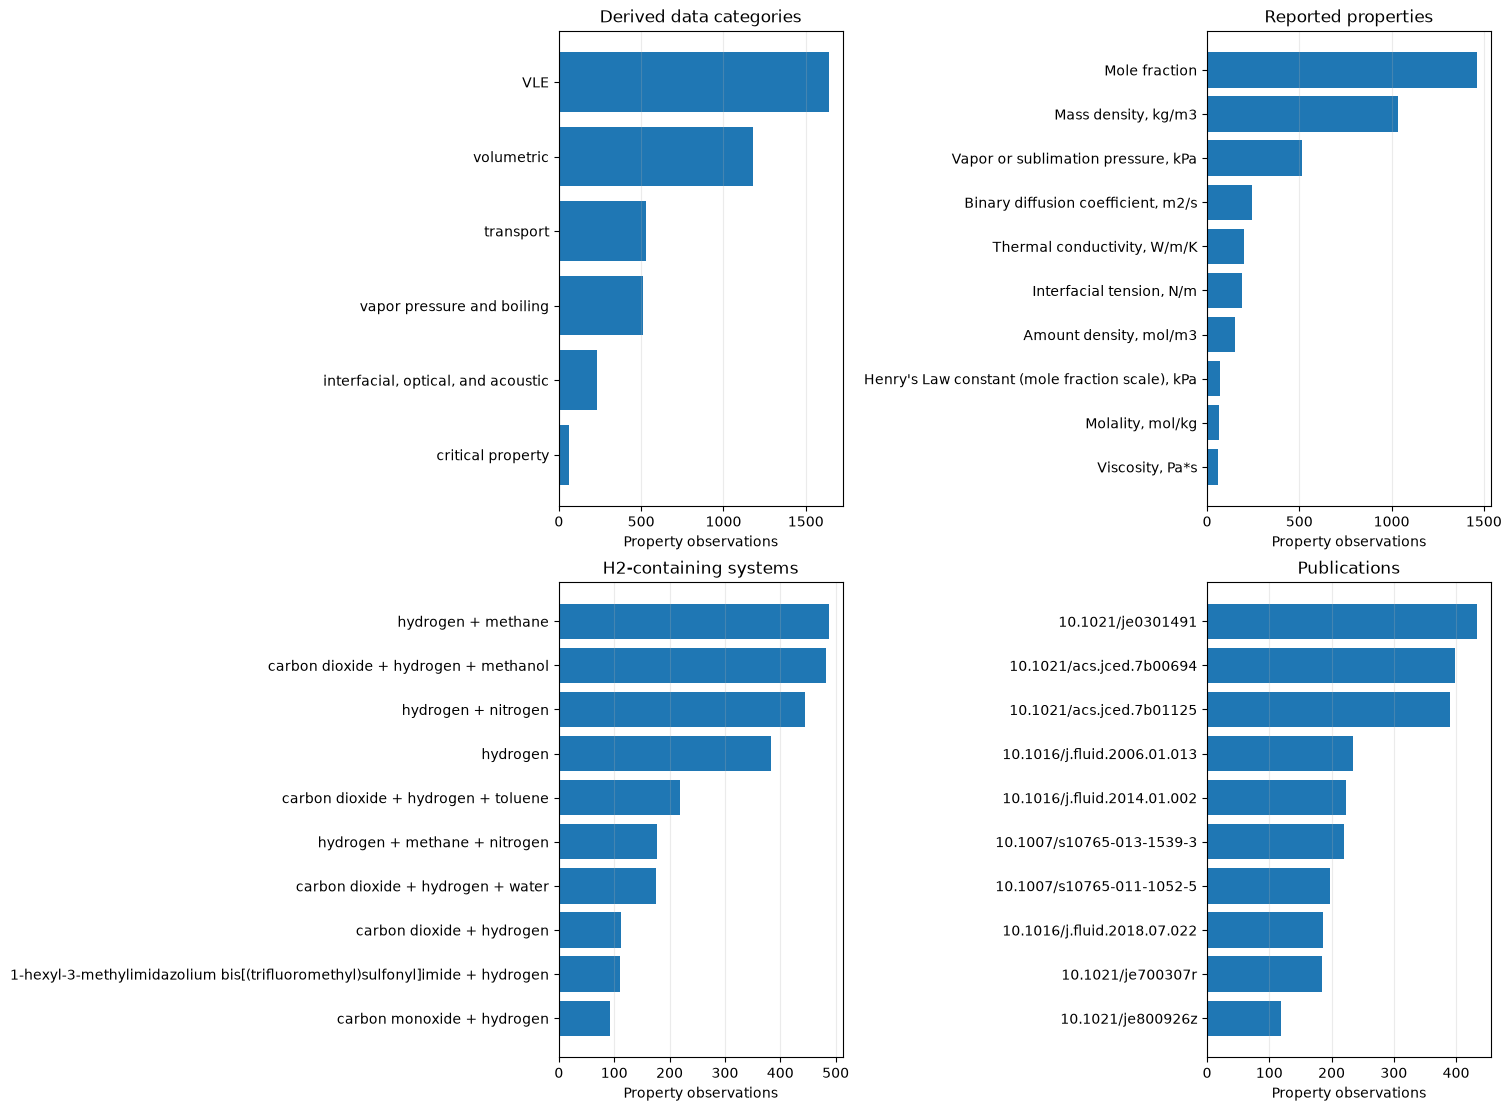

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
for axis, field, title in (
    (axes[0, 0], "data_types", "Derived data categories"),
    (axes[0, 1], "properties", "Reported properties"),
    (axes[1, 0], "systems", "H2-containing systems"),
    (axes[1, 1], "publications", "Publications"),
):
    frame = ranking_frames[field].sort_values("count")
    axis.barh(frame["label"], frame["count"])
    axis.set_title(title)
    axis.set_xlabel("Property observations")
    axis.grid(axis="x", alpha=0.25)
plt.show()

## Recoveries, failures, and limitations

In [8]:
recovery_frame = pd.DataFrame(
    [
        {
            "XML member": item.xml_member_name,
            "JSON member": item.json_member_name,
            "XML error": item.error_message,
        }
        for item in analysis.recoveries
    ]
)
if recovery_frame.empty:
    print("No H2-prefiltered XML member required paired-JSON recovery.")
else:
    display(recovery_frame)

No H2-prefiltered XML member required paired-JSON recovery.


In [9]:
failure_frame = pd.DataFrame(
    [
        {
            "archive_member": item.member_name,
            "error_type": item.error_type,
            "message": item.message,
        }
        for item in analysis.failures
    ]
)
if failure_frame.empty:
    print("No H2-prefiltered member remained undecodable.")
else:
    display(failure_frame)

No H2-prefiltered member remained undecodable.


- “All” means every matching supported `PureOrMixtureData` dataset in the
  pinned snapshot, whose publication cutoff is 2019.
- `ReactionData` is not associated with components in the v0.1 typed model
  and is therefore outside this component-specific census.
- Counts measure stored property observations, not independent experiments or
  critically evaluated recommended values.
- NIST/TRC checks representation completeness but does not critically
  evaluate the underlying measurements; consult the original publications
  before model calibration or validation.